# Расчет фрактальной размерности береговой линии методом Box Counting

*Университет Иннополис*

*Основы математического и компьютерного моделирования*

**Выполнили:** Лакпажап Дан-Хаяа B24-MFAI-04, Хадралинова Полина B24-MFAI-03

*2026 г.*

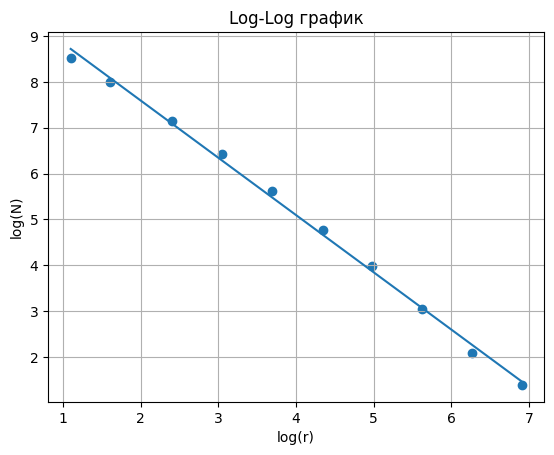

Dataset: britain.png | Global D = 1.2491


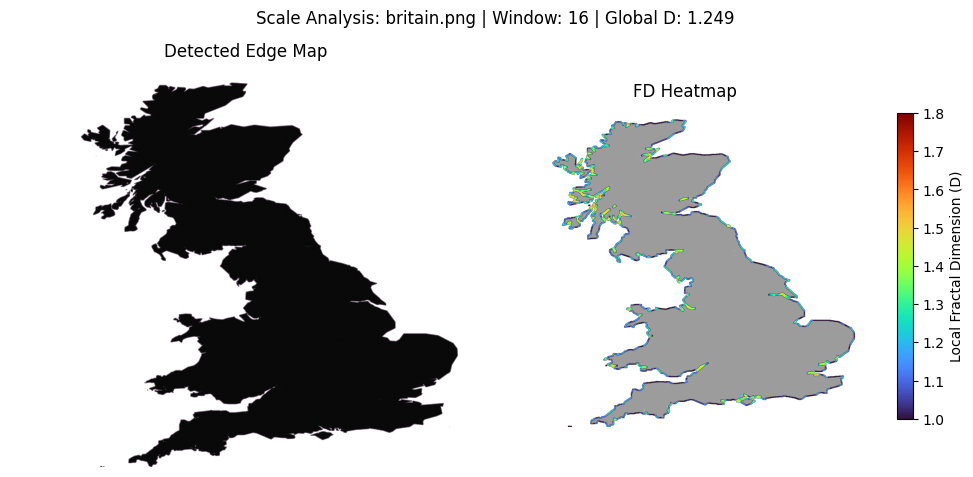

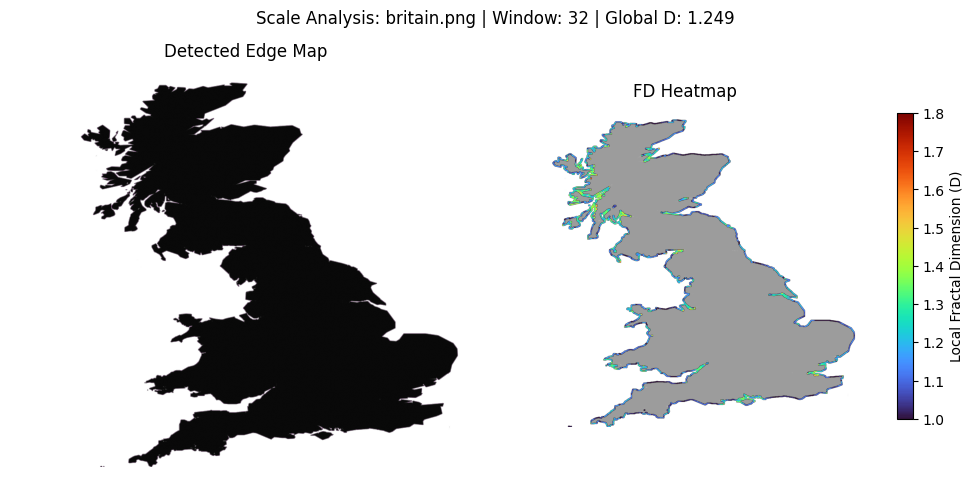

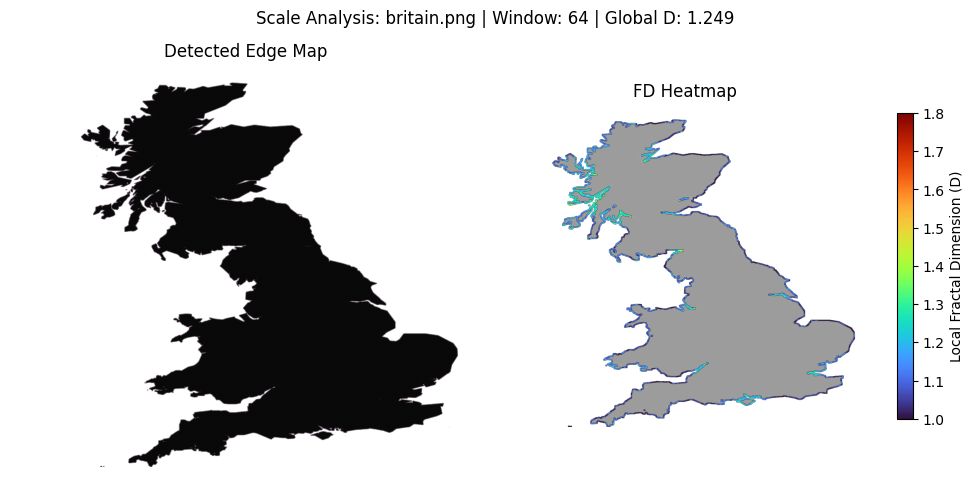

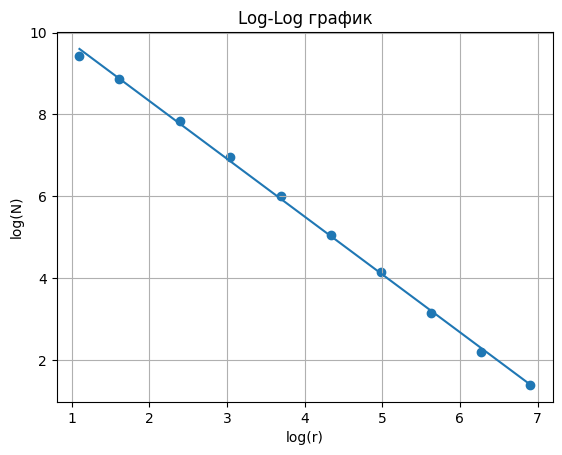

Dataset: e_coast.png | Global D = 1.4131


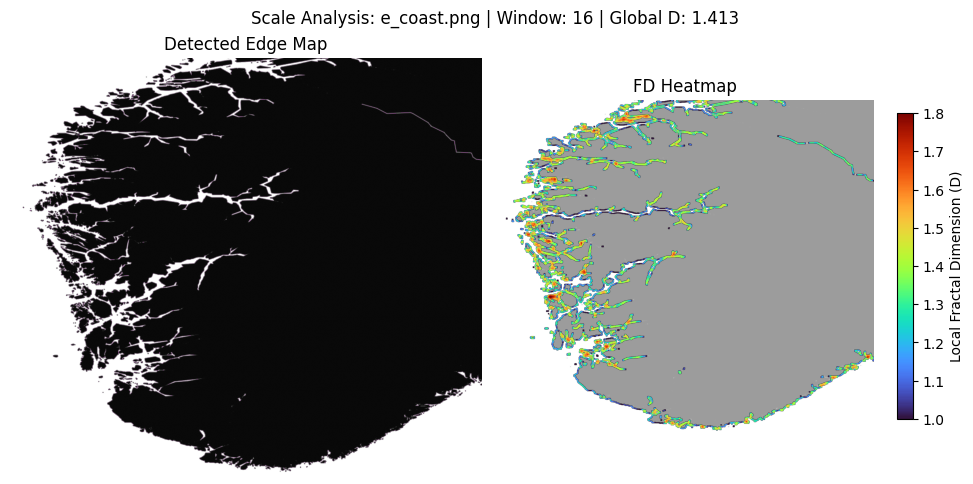

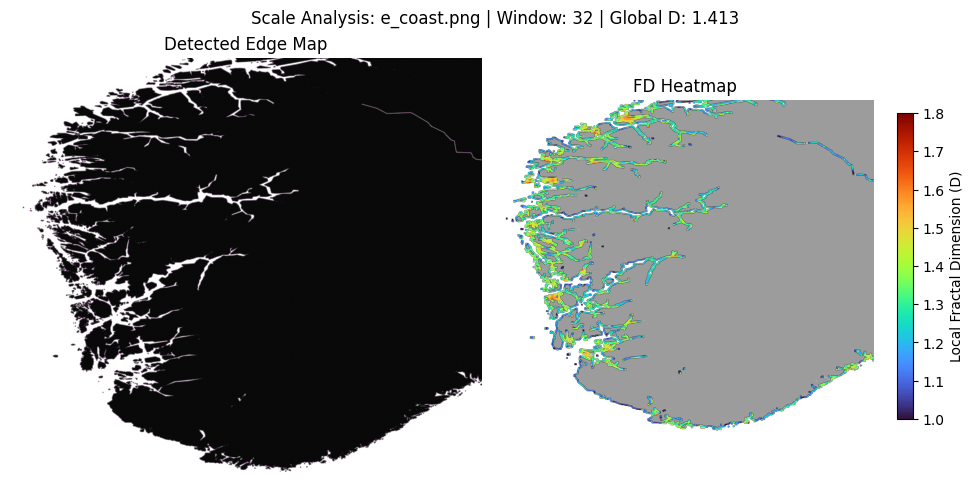

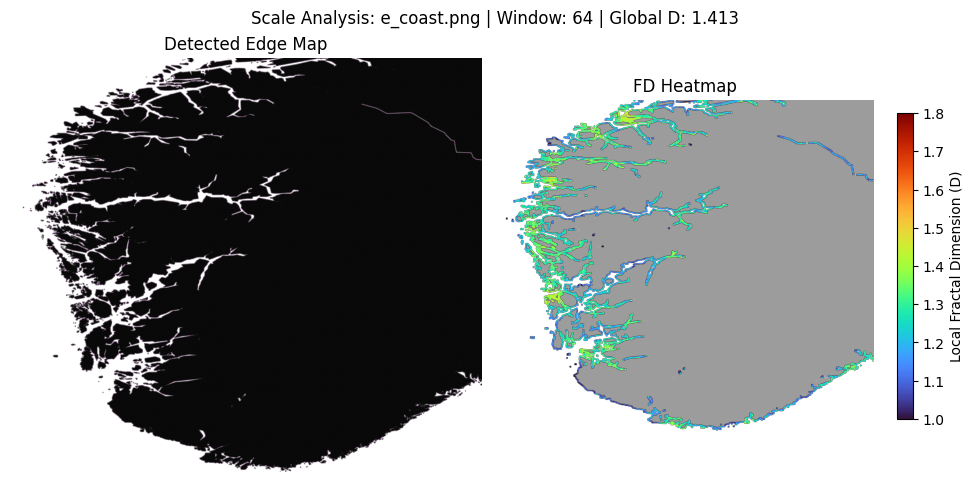

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def box_counter(img_matrix, r):
    """
    Вычисляет количество непустых блоков N(r) для заданного масштаба r.
    """
    h, w = img_matrix.shape
    pad_h, pad_w = (r - h % r) % r, (r - w % r) % r
    
    if pad_h > 0 or pad_w > 0:
        img_padded = np.pad(img_matrix, ((0, pad_h), (0, pad_w)), mode='constant')
    else:
        img_padded = img_matrix
        
    grid_h, grid_w = img_padded.shape[0] // r, img_padded.shape[1] // r
    blocks = img_padded.reshape(grid_h, r, grid_w, r)
    
    return np.count_nonzero(blocks.sum(axis=(1, 3)))

def get_min_n(img_matrix, r, max_shifts=4):
    """
    Определяет минимальное покрытие N(r) путем трансляции сетки (Continuous Box-Counting).
    """
    min_n = float('inf')
    shifts = min(r, max_shifts)
    
    for dy in range(shifts):
        for dx in range(shifts):
            shifted = img_matrix[dy:, dx:]
            if shifted.size == 0: continue
            
            n = box_counter(shifted, r)
            if n < min_n: 
                min_n = n
    return min_n

def calculate_fd(img_matrix, scales, plot=False):
    """
    Аппроксимация фрактальной размерности Минковского методом наименьших квадратов.
    """
    n_values = []
    valid_scales = []
    
    for r in scales:
        n = get_min_n(img_matrix, r)
        if n > 0:
            n_values.append(n)
            valid_scales.append(r)
            
    if len(n_values) < 2:
        return 1.0
        
    coeffs = np.polyfit(np.log(valid_scales), np.log(n_values), 1)
    
    if plot:
        plt.figure()
        plt.scatter(np.log(valid_scales), np.log(n_values))
        plt.plot(np.log(valid_scales), np.polyval(coeffs, np.log(valid_scales)))
        plt.xlabel("log(r)")
        plt.ylabel("log(N)")
        plt.title("Log-Log график")
        plt.grid()
        plt.show()
        
    return -coeffs[0]



def process_coastline(image_path, win_sizes=[16, 32, 64], local_scales=np.array([2,4,8,16])):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    edges = (cv2.Canny(binary, 100, 200) > 0).astype(np.uint8)

    # Глобальный анализ
    global_scales = np.unique(np.floor(np.logspace(0.5, 3, 10)).astype(int))
    global_scales = global_scales[global_scales > 0]
    global_fd = calculate_fd(edges, global_scales, plot=True) 
    
    print(f"Dataset: {image_path} | Global D = {global_fd:.4f}")

    # Локальный анализ методом скользящего окна
    for win_size in win_sizes:
        h, w = edges.shape
        heatmap = np.zeros((h, w), dtype=np.float32)
        y_coords, x_coords = np.where(edges > 0)
        
        pad = win_size // 2
        padded_edges = np.pad(edges, pad, mode='constant')

        for y, x in zip(y_coords, x_coords):
            window = padded_edges[y : y + win_size, x : x + win_size]
            heatmap[y, x] = calculate_fd(window, local_scales)

        _visualize_results(img, edges, heatmap, win_size, global_fd, image_path)

def _visualize_results(img, edges, heatmap, win_size, global_fd, path):
    """
    Визуализация пространственного распределения локальной фрактальной размерности.
    """
    vis_heatmap = cv2.dilate(heatmap, np.ones((3,3), np.uint8), iterations=2)
    
    plt.figure(figsize=(10, 5))
    plt.suptitle(f"Scale Analysis: {path} | Window: {win_size} | Global D: {global_fd:.3f}")
    
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.imshow(np.ma.masked_where(edges == 0, edges), cmap='spring', alpha=0.6)
    plt.title("Detected Edge Map")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    masked_hm = np.ma.masked_where(vis_heatmap <= 0.5, vis_heatmap)
    plt.imshow(img, cmap='gray', alpha=0.4)
    plt.imshow(masked_hm, cmap='turbo', vmin=1.0, vmax=1.8)
    plt.colorbar(label='Local Fractal Dimension (D)', shrink=0.7)
    plt.title("FD Heatmap")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    for fname in ["britain.png", "e_coast.png"]:
        process_coastline(fname)

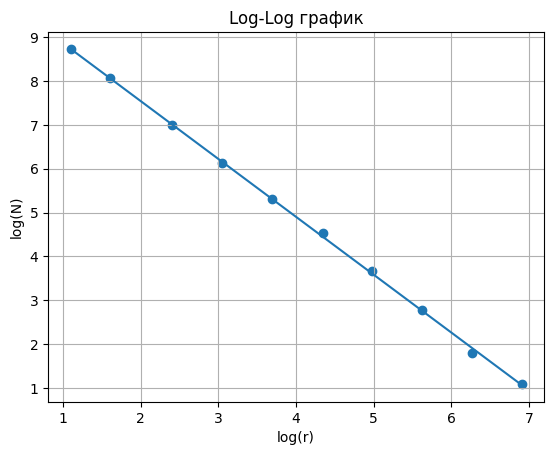

Dataset: snowflake.png | Global D = 1.3181


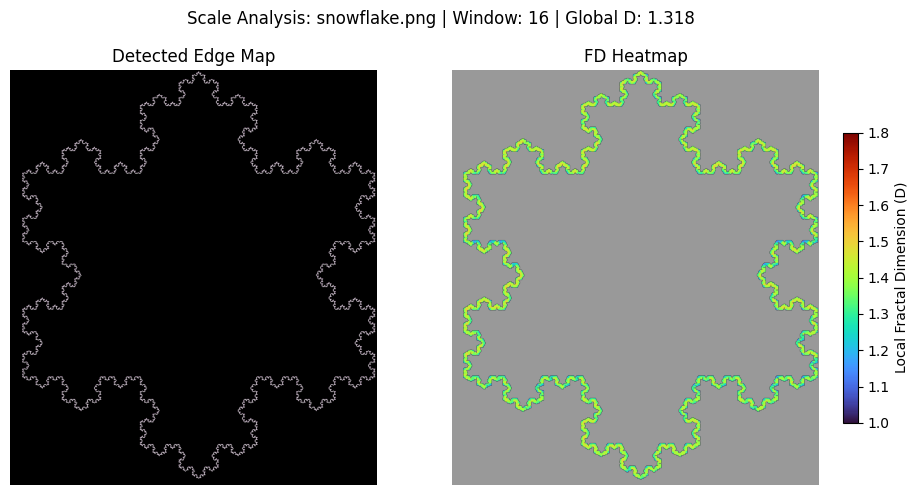

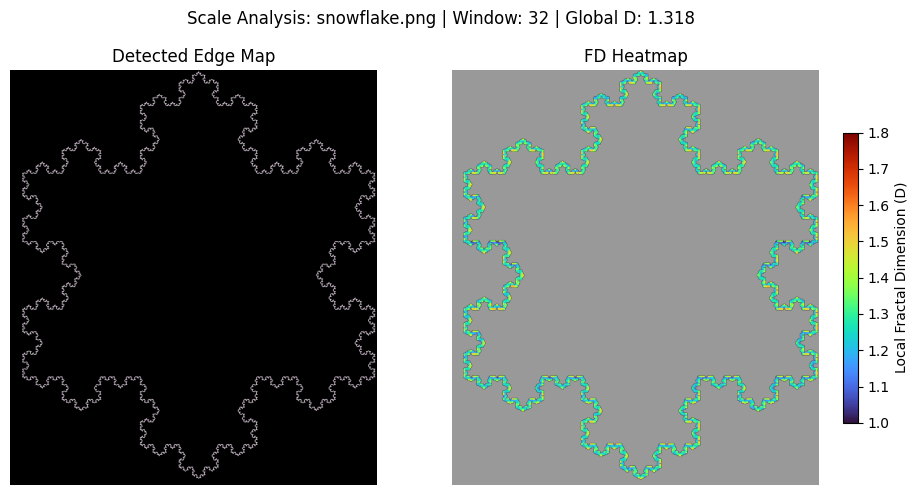

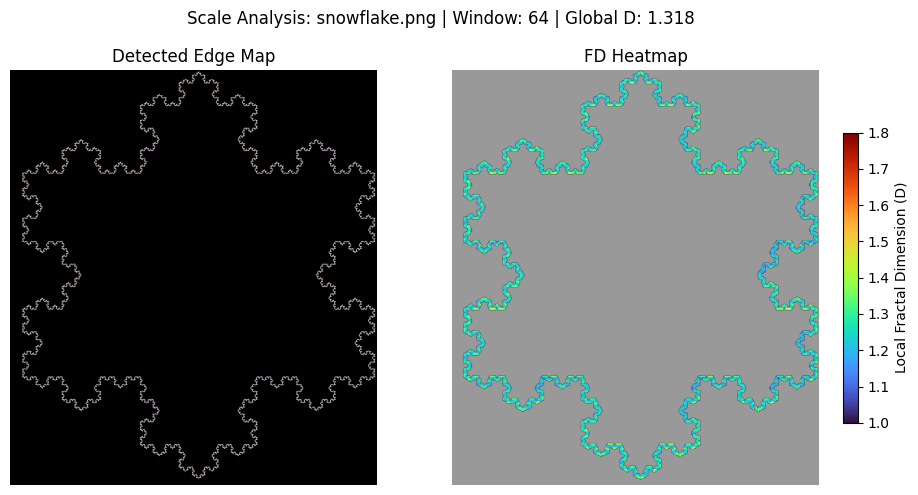

In [13]:
process_coastline("snowflake.png")